# LING 498 Hackathon — Prompt 7

## POS bigrams as mini-constructions

**Category:** Syntax (construction proxy)

**Question:** Do POS bigrams show Zipf-like behavior as a proxy for constructions?

- **Data:** Brown tokens + POS tags.
- **Items to Count:** Tag pairs: `(tag_i, tag_{i+1})` from `nltk.bigrams(tags)`.

**Steps**
- POS-tag a corpus slice.
- Build tag bigrams.
- Run Zipf report/plot.
- Interpret top 3 as “mini-constructions” (e.g., DT NN, IN DT).

**Deliverable:** Top-15 POS bigrams + one “construction story” + one limitation.

In [76]:
import re
import nltk
from nltk.corpus import brown
from nltk import FreqDist
from nltk import bigrams


In [ ]:
# Helper functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", item_name="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Tag Pair Types: {len(ranked)} | Tags Pairs {sum(c for _,c in ranked)}")
    print("Top POS Bigrams:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Optional plotting cell (instructor can pre-enable if matplotlib is available)
def zipf_plot(ranked, n=1000, title="Top 1000 _______"):
    import matplotlib.pyplot as plt
    ranks = list(range(1, min(n, len(ranked))+1))
    freqs = [ranked[i-1][1] for i in ranks]
    plt.figure(figsize=(6,4))
    plt.loglog(ranks, freqs, marker='.')
    plt.xlabel("rank (log)")
    plt.ylabel("frequency (log)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# Load tokens
tokens = brown.words(categories='news')

# Filter tokens that are only punctuation
words = [
    token
    for token in tokens
    if not re.fullmatch(r"\W+", token) 
]

In [87]:
# POS-tag with tokens
tagged = nltk.pos_tag(words)

# Extract only the tags
tags = [tag for word, tag in tagged]

# Build POS bigrams
tag_bigrams = list(nltk.bigrams(tags))


=== Brown Corpus (News) POS Bigrams ===
Tag Pair Types: 696 | Tags Pairs 88591
Top POS Bigrams:
 1. ('NNP', 'NNP')                           6040
 2. ('IN', 'DT')                             4568
 3. ('NN', 'IN')                             4414
 4. ('DT', 'NN')                             4373
 5. ('JJ', 'NN')                             2944
 6. ('DT', 'JJ')                             2420
 7. ('IN', 'NNP')                            1893
 8. ('NN', 'NN')                             1629
 9. ('DT', 'NNP')                            1542
10. ('NNS', 'IN')                            1533
11. ('TO', 'VB')                             1281
12. ('IN', 'NN')                             1260
13. ('JJ', 'NNS')                            1218
14. ('NNP', 'IN')                            1172
15. ('NNP', 'NN')                            1146

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 0.661
 f1/(3*f3) = 0.456
 f1/(4*f4) = 0.345
 f1/(5*f5) = 0.41


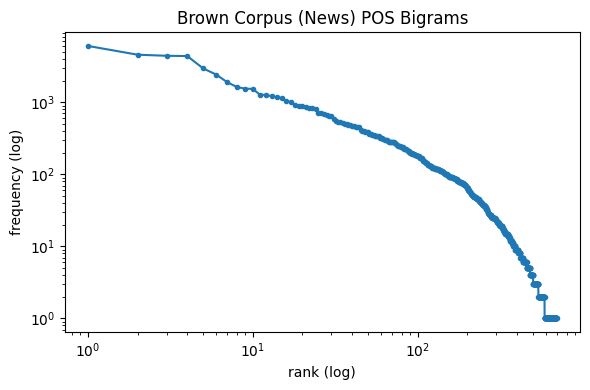

In [88]:
ranked = zipf_quick_report(
    tag_bigrams,
    title="Brown Corpus (News) POS Bigrams",
    item_name="tag pairs"
)

zipf_plot(
    ranked,
    title="Brown Corpus (News) POS Bigrams"
)

In [89]:
print("Top 3 POS bigrams:\n")

for pair, count in ranked[:3]:
    print(pair, "->", count)

Top 3 POS bigrams:

('NNP', 'NNP') -> 6040
('IN', 'DT') -> 4568
('NN', 'IN') -> 4414


| POS Bigram       | Typical construction                          |
| ---------------- | --------------------------------------------- |
| `('NNP', 'NNP')` | Proper nouns ("New York", "John Kennedy")     |
| `('IN', 'DT')`   | Preposition + determiner ("in the", "of the") |
| `('DT', 'NN')`   | Determiner + noun ("the house")               |
| `('NN', 'IN')`   | Noun + preposition ("president of")           |
| `('JJ', 'NN')`   | Adjective + noun ("large city")               |
